
# Tarea 0: Setup & First Contact with All Three Datasets
## IELE756 --- Preparación y Análisis de Datos
**Team members**: Macarena Fraga, Sebastian Bolomey

**Region**: Region Metropolitana

**Date**: 12.03.2026

## Import: Pandas, Matplotlib

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
print("Hello, IELE756!")
print(f"pandas version: {pd.__version__}")

Hello, IELE756!
pandas version: 2.3.3


# Part 1: Census 2024
---

## 1.1 Load
Loading the data

In [ ]:
persona = pd.read_parquet(
    "personas_censo2024.parquet",
    columns=["region", "comuna", "sexo", "edad",
             "p27_nacionalidad", "p27_nacionalidad_rec",
             "escolaridad", "sit_fuerza_trabajo"],
)

## 1.2 Inspect
### 1.2.1 Number of rows and columns.

In [ ]:
persona.shape


(18480432, 8)

### 1.2.2 Data types

In [ ]:
persona.dtypes

region                    int32
comuna                    int32
sexo                      int32
edad                      int32
p27_nacionalidad          int32
p27_nacionalidad_rec      int32
escolaridad               int32
sit_fuerza_trabajo      float64
dtype: object

### 1.2.3 First 10 rows.

In [ ]:
persona.head(10)

,region,comuna,sexo,edad,p27_nacionalidad,p27_nacionalidad_rec,escolaridad,sit_fuerza_trabajo
0,5,5802,2,80,1,1,17,3.0
1,5,5802,1,52,1,1,14,1.0
2,5,5802,2,45,1,1,12,1.0
3,5,5802,2,8,1,1,2,NaN
4,4,4303,1,69,1,1,12,3.0
5,4,4303,2,65,1,1,12,3.0
6,4,4303,1,58,1,1,15,1.0
7,11,11202,2,-66,-66,1,8,1.0
8,11,11202,1,-66,-66,1,5,1.0
9,11,11202,1,-66,-66,1,3,NaN


### 1.2.4 Null values

In [ ]:
persona.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18480432 entries, 0 to 18480431
Data columns (total 8 columns):
 #   Column                Dtype  
---  ------                -----  
 0   region                int32  
 1   comuna                int32  
 2   sexo                  int32  
 3   edad                  int32  
 4   p27_nacionalidad      int32  
 5   p27_nacionalidad_rec  int32  
 6   escolaridad           int32  
 7   sit_fuerza_trabajo    float64
dtypes: float64(1), int32(7)
memory usage: 634.5 MB


## 1.3 Filter for "Region Metropolitana"

In [7]:
my_region = persona[persona["region"] == 13]
print(f"Rows in my region: {len(my_region):,}")

Rows in my region: 7,400,741


## 1.4 First look at nationality
Percentage of foreigners in the selected region.

In [ ]:
foreign = my_region["p27_nacionalidad_rec"] \
    .value_counts(normalize=True)
print(f"foreign-born: {foreign.get('Extranjero', 0):.1%}")

% foreign-born: 0.0%


# Part 2 - ENO: Notifiable Diseases
---

### 2.1 Load

In [12]:
eno = pd.read_csv(
    "20241218_base_eno_final.csv",
    sep=",", encoding="utf-8-sig")
print(f"Total rows: {len(eno):,}")
print(eno.columns.tolist())

/var/folders/p_/wy68s7v50tgdqfjf03r42hn00000gn/T/ipykernel_19327/3042248933.py:1: DtypeWarning: Columns (7,12,13,14,15,16,17,18,19,20,21,23,24,25,26,27,28,29,30,31,32,33,34,35,36) have mixed types. Specify dtype option on import or set low_memory=False.
  eno = pd.read_csv(


Total rows: 333,300
['_id', 'etapa_clinica', 'region', 'seremi', 'nacionalidad', 'cie_10_diagnostico', 'diagnostico', 'Autoctono', 'anho_notificacion', 'ENO', 'pueblo_indigena', 'nombre_instruccion', 'presenta_sintomas', 'sintomas', 'consumo_agua_no_potable', 'antecedente_teniasis', 'imagenologia', 'manifestaciones', 'existe_coinfeccion', 'via_transmision', 'n_parejas_sexuales', 'uso_preservativo', 'pais_contagio', 'paciente_inmunosuprimido', 'vih', 'pareja', 'exantema_mpox', 'factores_exposicion', 'neumonia', 'contacto_aves', 'genotipo_1', 'recuento_linfocitos', 'clasificacion_final_vih', 'etapa_vih_sida', 'hospitalizacion', 'nombre_primer_sintoma', 'SeroGrupo', 'sexo', 'grupo_edad', 'codigo_comuna_residencia']


**10 most common diagnoses reported in this file**

In [15]:
print(eno['diagnostico'].value_counts().head(10))

diagnostico
no aplica                                                                                                  69772
PAROTIDITIS, SIN COMPLICACIONES                                                                            47123
SIFILIS PRECOZ, LATENTE                                                                                    24812
SIFILIS TARDIA, LATENTE                                                                                    24269
INFECCION GONOCOCICA DEL TRACTO GENITOURINARIO INFERIOR SIN ABSCESO PERIURETRAL O DE GLANDULA ACCESORIA    15399
HEPATITIS AGUDA TIPO A, CON COMA HEPATICO                                                                  13475
TOS FERINA DEBIDA A BORDETELLA PERTUSSIS                                                                   12762
SIFILIS, NO ESPECIFICADA                                                                                   12615
INFECCION, GONOCOCICA, NO ESPECIFICADA                                              

**Regions in this file and number of data for each region.**

In [24]:
print(eno['region'].value_counts().head(17))

region
Región Metropolitana de Santiago                       126669
Región del Biobío                                       38592
Región de Valparaíso                                    36373
Región de Coquimbo                                      21373
Región de Antofagasta                                   18302
Región de Los Lagos                                     17829
Región de Tarapacá                                      13778
Región de la Araucanía                                  11593
Región del Libertador General Bernardo OHiggins         10765
Región del Maule                                        10128
Región de Atacama                                        7008
Región de Arica y Parinacota                             6541
Región de Los Ríos                                       5581
Región de Magallanes y la Antártica Chilena              3208
Región del Ñuble                                         2818
Región de Aysén del General Carlos Ibáñez del Campo      2690
D

**Percentage of ENO in the Metropolitan Region**

In [45]:
metrop = eno["region"] \
    .value_counts(normalize=True)
print(f"% ena in RM: {metrop.get('Región Metropolitana de Santiago', 0):.1%}")

% ena in RM: 38.0%


### 2.2 Filter to region
Filtering data for the assigned region.

In [ ]:
eno_region = eno[eno["region"] == "Región Metropolitana de Santiago"]
print(f"Rows in my region: {len(eno_region):,}".replace(",", "."))

Rows in my region: 126.669


### 2.3 Notifications by year
Number of notifications per year

In [ ]:
notifsxyear = eno_region["anho_notificacion"].value_counts().sort_index()
print(notifsxyear)

anho_notificacion
2007     3930
2008     3830
2009     4015
2010     4693
2011     6151
2012     5857
2013     6006
2014     6005
2015     6129
2016     6023
2017    10865
2018    13256
2019    10287
2020     7182
2021     7457
2022    10496
2023     9395
2024     5092
Name: count, dtype: int64


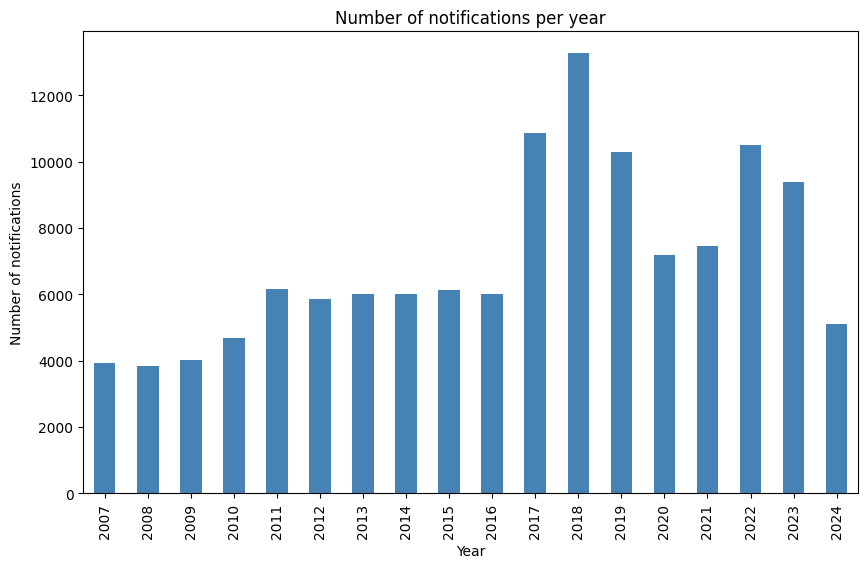

In [ ]:

# Creating a bar chart
notifsxyear.plot(kind="bar", figsize=(10, 6), color="steelblue")

# Labels and title
plt.title("Number of notifications per year")
plt.xlabel("Year")
plt.ylabel("Number of notifications")

#Display chart
plt.show()

### 2.4 - Top 5 diseases
5 most frequently notified diseases in Region Metropolitana

In [ ]:
top_5_diseases= eno_region["ENO"].value_counts().head(5)
print(top_5_diseases)

ENO
Sifilis                 40928
VIH                     29097
Parotiditis             15493
Infección gonocócica     8766
Hepatitis B              7565
Name: count, dtype: int64


### Display the top 5 most frequently notified diseases in Region Metropolitana as an horizontal bar chart

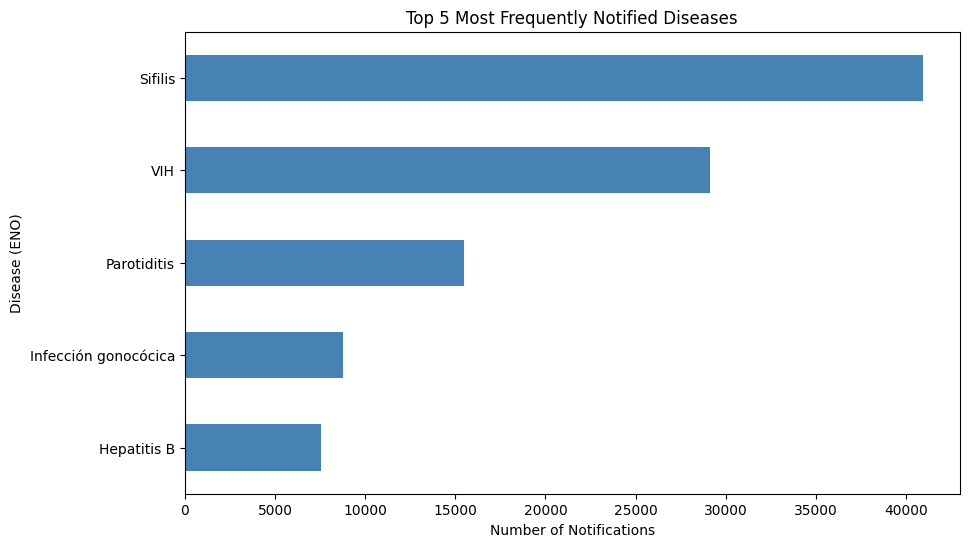

In [ ]:
# Most frequent disease appears at the top of the chart
top_5_diseases = top_5_diseases.sort_values(ascending = True)

# Creating horizontal bar chart
top_5_diseases.plot(kind="barh", figsize=(10, 6), color="steelblue")

# Labels and title
plt.title("Top 5 Most Frequently Notified Diseases")
plt.xlabel("Number of Notifications")
plt.ylabel("Disease (ENO)")

#Display chart
plt.show()

### 2.5 Nationality distribution

In [ ]:
eno_region["nacionalidad"].value_counts()

nacionalidad
Desconocido    55863
Chile          47093
Extranjero     23713
Name: count, dtype: int64